In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 7043, Columns: 21


In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head(10))

object
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Fixed! New dtype:", df['TotalCharges'].dtype)

Fixed! New dtype: float64


In [16]:
print(df['TotalCharges'].isnull().sum())

11


In [17]:
df['TotalCharges'].fillna(0, inplace=True)
print("Missing values remaining:", df['TotalCharges'].isnull().sum())

Missing values remaining: 0


/tmp/ipykernel_57/3288588607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [18]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [19]:
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [20]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDataset shape:", df.shape)

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Dataset shape: (7043, 21)


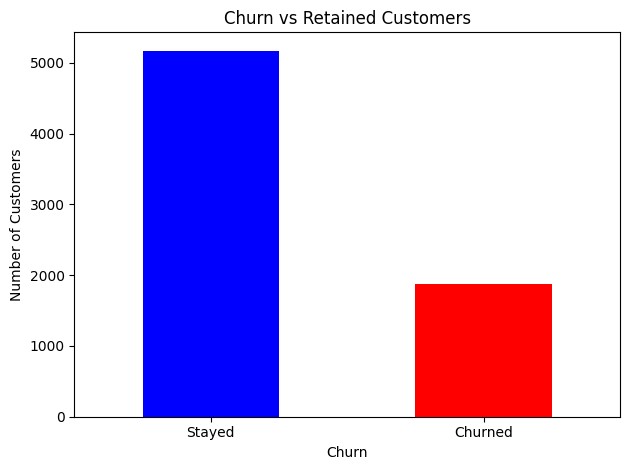

In [22]:
df['Churn'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Churn vs Retained Customers')
plt.xticks([0, 1], ['Stayed', 'Churned'], rotation=0)
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

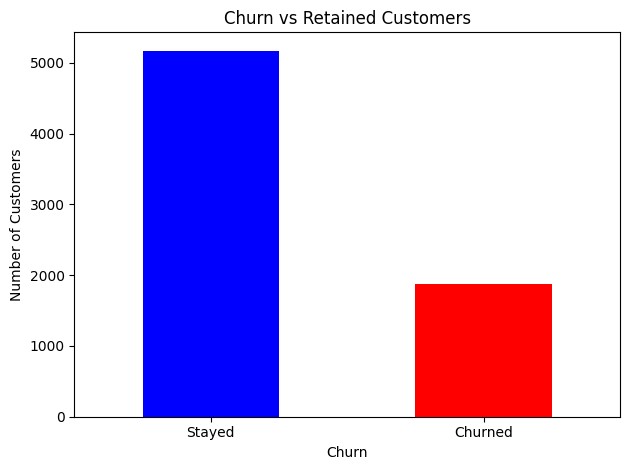

In [23]:
df['Churn'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Churn vs Retained Customers')
plt.xticks([0, 1], ['Stayed', 'Churned'], rotation=0)
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('churn_chart.png', dpi=150, bbox_inches='tight')  # ← add this line
plt.show()

In [24]:
df['tenure_score'] = (df['tenure'] / df['tenure'].max()) * 30

print("Tenure score sample:")
print(df['tenure_score'].head())

Tenure score sample:
0     0.416667
1    14.166667
2     0.833333
3    18.750000
4     0.833333
Name: tenure_score, dtype: float64


In [25]:
df['charges_score'] = (df['MonthlyCharges'] / df['MonthlyCharges'].max()) * 25

print("Charges score sample:")
print(df['charges_score'].head())

Charges score sample:
0     6.284211
1    11.989474
2    11.336842
3     8.905263
4    14.884211
Name: charges_score, dtype: float64


In [26]:
df['techsupport_score'] = df['TechSupport'].map({'Yes': 20, 'No': 0, 'No internet service': 10})

print("Tech support score sample:")
print(df['techsupport_score'].value_counts())

Tech support score sample:
techsupport_score
0     3473
20    2044
10    1526
Name: count, dtype: int64


In [27]:
df['security_score'] = df['OnlineSecurity'].map({'Yes': 25, 'No': 0, 'No internet service': 12})

print("Security score sample:")
print(df['security_score'].value_counts())

Security score sample:
security_score
0     3498
25    2019
12    1526
Name: count, dtype: int64


In [28]:
df['health_score'] = (
    df['tenure_score'] +
    df['charges_score'] +
    df['techsupport_score'] +
    df['security_score']
)

print("Health Score Summary:")
print(df['health_score'].describe().round(2))

Health Score Summary:
count    7043.00
mean       44.86
std        23.26
min         5.35
25%        26.77
50%        41.28
75%        59.70
max       100.00
Name: health_score, dtype: float64


In [29]:
def assign_tier(score):
    if score >= 70:
        return 'Green'    # Healthy
    elif score >= 40:
        return 'Yellow'   # At Risk
    else:
        return 'Red'      # Danger Zone

df['health_tier'] = df['health_score'].apply(assign_tier)

print("Health Tier Distribution:")
print(df['health_tier'].value_counts())

Health Tier Distribution:
health_tier
Red       3392
Yellow    2500
Green     1151
Name: count, dtype: int64


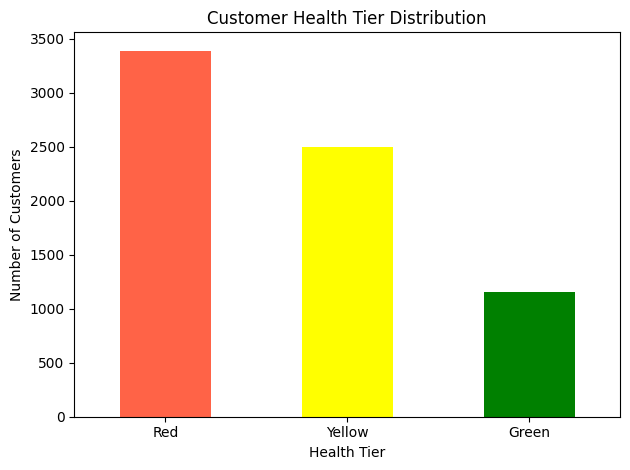

In [30]:
colors = {'Green': 'green', 'Yellow': 'Yellow', 'Red': 'tomato'}
tier_counts = df['health_tier'].value_counts()

tier_counts.plot(kind='bar', color=[colors[t] for t in tier_counts.index])
plt.title('Customer Health Tier Distribution')
plt.xlabel('Health Tier')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('health_tier_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
validation = df.groupby('health_tier')['Churn'].mean() * 100
print("Churn rate per health tier (%):")
print(validation.round(2))

Churn rate per health tier (%):
health_tier
Green      8.69
Red       40.12
Yellow    16.32
Name: Churn, dtype: float64


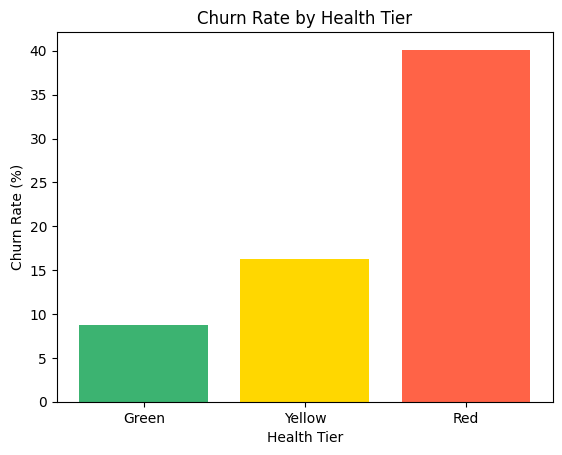

In [33]:
tiers = ['Green', 'Yellow', 'Red']
churn_rates = [8.69, 16.32, 40.12]
colors = ['mediumseagreen', 'gold', 'tomato']
plt.bar(tiers, churn_rates, color=colors)
plt.title('Churn Rate by Health Tier')
plt.xlabel('Health Tier')
plt.ylabel('Churn Rate (%)')
plt.savefig('churn_by_tier.png')
plt.show()

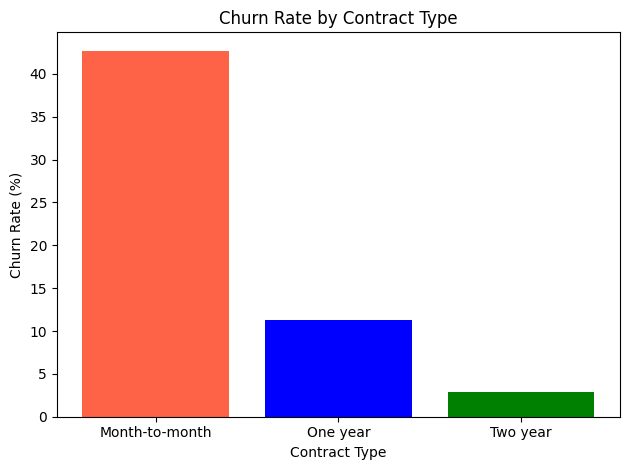

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [35]:
contract_churn = df.groupby('Contract')['Churn'].mean() * 100

plt.bar(contract_churn.index, contract_churn.values, color=['tomato', 'blue', 'green'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('contract_churn.png')
plt.show()

print(contract_churn.round(2))

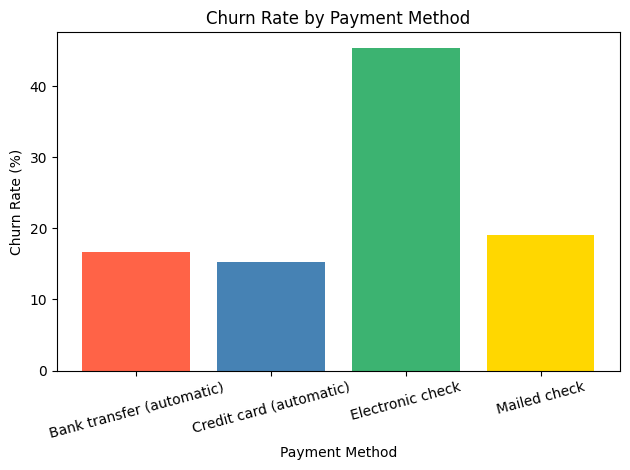

PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64


In [36]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100

plt.bar(payment_churn.index, payment_churn.values, color=['tomato', 'steelblue', 'mediumseagreen', 'gold'])
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('payment_churn.png')
plt.show()

print(payment_churn.round(2))

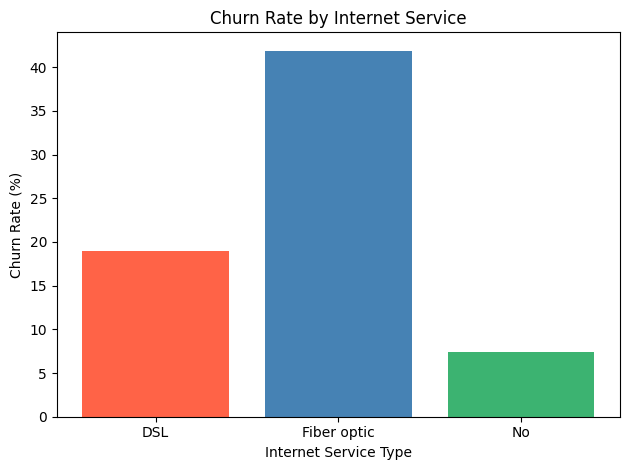

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


In [37]:
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100

plt.bar(internet_churn.index, internet_churn.values, color=['tomato', 'steelblue', 'mediumseagreen'])
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('internet_churn.png')
plt.show()

print(internet_churn.round(2))

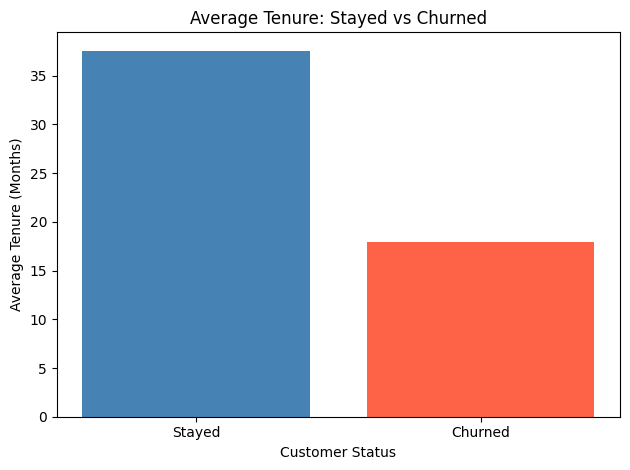

Churn
0    37.57
1    17.98
Name: tenure, dtype: float64


In [38]:
tenure_churn = df.groupby('Churn')['tenure'].mean()

plt.bar(['Stayed', 'Churned'], tenure_churn.values, color=['steelblue', 'tomato'])
plt.title('Average Tenure: Stayed vs Churned')
plt.xlabel('Customer Status')
plt.ylabel('Average Tenure (Months)')
plt.tight_layout()
plt.savefig('tenure_churn.png')
plt.show()

print(tenure_churn.round(2))

In [39]:
tier_summary = df.groupby('health_tier').agg(
    Total_Customers = ('customerID', 'count'),
    Churned_Customers = ('Churn', 'sum'),
    Churn_Rate = ('Churn', 'mean')
).reset_index()

tier_summary['Churn_Rate'] = (tier_summary['Churn_Rate'] * 100).round(2)

print(tier_summary)

  health_tier  Total_Customers  Churned_Customers  Churn_Rate
0       Green             1151                100        8.69
1         Red             3392               1361       40.12
2      Yellow             2500                408       16.32


In [40]:
contract_summary = df.groupby('Contract').agg(
    Total_Customers = ('customerID', 'count'),
    Churned_Customers = ('Churn', 'sum'),
    Churn_Rate = ('Churn', 'mean')
).reset_index()

contract_summary['Churn_Rate'] = (contract_summary['Churn_Rate'] * 100).round(2)

print(contract_summary)

         Contract  Total_Customers  Churned_Customers  Churn_Rate
0  Month-to-month             3875               1655       42.71
1        One year             1473                166       11.27
2        Two year             1695                 48        2.83


In [41]:
payment_summary = df.groupby('PaymentMethod').agg(
    Total_Customers = ('customerID', 'count'),
    Churned_Customers = ('Churn', 'sum'),
    Churn_Rate = ('Churn', 'mean')
).reset_index()

payment_summary['Churn_Rate'] = (payment_summary['Churn_Rate'] * 100).round(2)

print(payment_summary)

               PaymentMethod  Total_Customers  Churned_Customers  Churn_Rate
0  Bank transfer (automatic)             1544                258       16.71
1    Credit card (automatic)             1522                232       15.24
2           Electronic check             2365               1071       45.29
3               Mailed check             1612                308       19.11


In [42]:

writer = pd.ExcelWriter('saas_churn_analysis.xlsx', engine='openpyxl')


df.to_excel(writer, sheet_name='Customer Data', index=False)

tier_summary.to_excel(writer, sheet_name='Health Tier Summary', index=False)

contract_summary.to_excel(writer, sheet_name='Contract Analysis', index=False)

payment_summary.to_excel(writer, sheet_name='Payment Analysis', index=False)

writer.close()

print("Excel file saved successfully!")
print("File name: saas_churn_analysis.xlsx")

Excel file saved successfully!
File name: saas_churn_analysis.xlsx


In [43]:
verify = pd.read_excel('saas_churn_analysis.xlsx', sheet_name=None)

print("Sheets in your Excel file:")
for sheet_name, data in verify.items():
    print(f"  '{sheet_name}' → {data.shape[0]} rows, {data.shape[1]} columns")

Sheets in your Excel file:
  'Customer Data' → 7043 rows, 27 columns
  'Health Tier Summary' → 3 rows, 4 columns
  'Contract Analysis' → 3 rows, 4 columns
  'Payment Analysis' → 4 rows, 4 columns
